# 02 Exploratory Data Analysis

This notebook explores the cleaned 2025 Stack Overflow Developer Survey data prepared in `01_data_check.ipynb`.

The goal is to understand patterns in:
- job satisfaction
- career change consideration
- learning pathways
- active learning status
- compensation
- experience
- AI attitudes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:

df = pd.read_csv("../data/processed/stackoverflow_2025_project_cleaned.csv")

df.head()

,ResponseId,JobSat,NewRole,LearnCodeChoose,LearnCode,LearnCodeAI,EdLevel,YearsCode,WorkExp,ConvertedCompYearly,...,RemoteWork,Country,AISelect,AIThreat,high_job_sat,career_change_considered,active_learner,log_salary,WorkExp_clean,YearsCode_clean
0,1,10.0,I have neither consider or transitioned into a...,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...","Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",14.0,8.0,61256.0,...,Remote,Ukraine,"Yes, I use AI tools monthly or infrequently",I'm not sure,1.0,0.0,1.0,11.022833,8.0,14.0
1,2,9.0,I have transitioned into a new career and/or i...,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...","Associate degree (A.A., A.S., etc.)",10.0,2.0,104413.0,...,"Hybrid (some in-person, leans heavy to flexibi...",Netherlands,"Yes, I use AI tools weekly",I'm not sure,1.0,1.0,1.0,11.556119,2.0,10.0
2,3,8.0,I have transitioned into a new career and/or i...,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",12.0,10.0,53061.0,...,Missing,Ukraine,"Yes, I use AI tools daily",No,1.0,1.0,1.0,10.879216,10.0,12.0
3,4,6.0,I have neither consider or transitioned into a...,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5.0,4.0,36197.0,...,Remote,Ukraine,"Yes, I use AI tools weekly",No,0.0,0.0,1.0,10.496759,4.0,5.0
4,5,7.0,I have neither consider or transitioned into a...,"No, I am not new to coding and did not learn n...",Missing,"Yes, I learned how to use AI-enabled tools for...","Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",22.0,21.0,60000.0,...,Missing,Ukraine,"Yes, I use AI tools weekly",No,0.0,0.0,0.0,11.002117,21.0,22.0


In [3]:
df.shape

(49191, 24)

In [4]:
df.columns.tolist()

['ResponseId',
 'JobSat',
 'NewRole',
 'LearnCodeChoose',
 'LearnCode',
 'LearnCodeAI',
 'EdLevel',
 'YearsCode',
 'WorkExp',
 'ConvertedCompYearly',
 'Age',
 'Employment',
 'DevType',
 'OrgSize',
 'RemoteWork',
 'Country',
 'AISelect',
 'AIThreat',
 'high_job_sat',
 'career_change_considered',
 'active_learner',
 'log_salary',
 'WorkExp_clean',
 'YearsCode_clean']

## Job Satisfaction Distribution

`JobSat` is a 0–10 scale measuring how satisfied respondents are in their current professional developer role.

In [5]:
jobsat_counts = df["JobSat"].value_counts(dropna=False).sort_index()
jobsat_counts

JobSat
0.0       242
1.0       165
2.0       439
3.0       811
4.0       803
5.0      1896
6.0      3230
7.0      5590
8.0      6972
9.0      3598
10.0     2924
NaN     22521
Name: count, dtype: int64

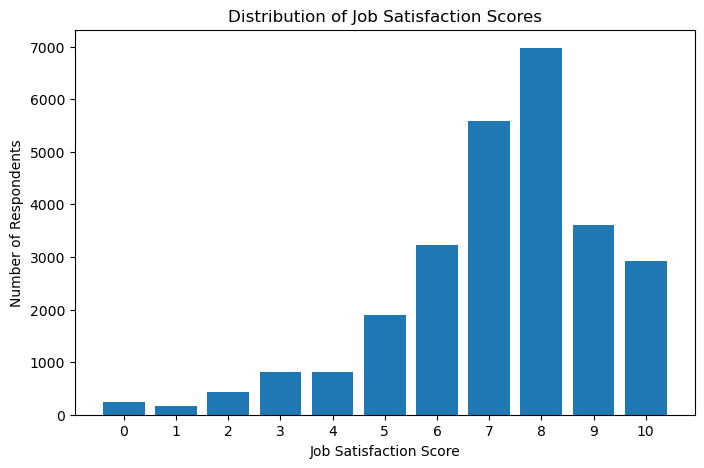

In [6]:
jobsat_counts_no_missing = df["JobSat"].dropna().value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(jobsat_counts_no_missing.index, jobsat_counts_no_missing.values)
plt.xlabel("Job Satisfaction Score")
plt.ylabel("Number of Respondents")
plt.title("Distribution of Job Satisfaction Scores")
plt.xticks(range(0, 11))
plt.show()

In [7]:
df["JobSat"].describe()

count    26670.000000
mean         7.201950
std          1.997245
min          0.000000
25%          6.000000
50%          8.000000
75%          8.000000
max         10.000000
Name: JobSat, dtype: float64

## Career Change Consideration

The `NewRole` column asks whether respondents considered a career change or transitioned into a new role in the past year. This project converts that response into a binary variable called `career_change_considered`.

In [8]:
df["NewRole"].value_counts(dropna=False)

NewRole
I have neither consider or transitioned into a new career or industry          16205
NaN                                                                            13664
I have somewhat considered changing my career and/or the industry I work in    10233
I have strongly considered changing my career and/or the industry I work in     5253
I have transitioned into a new career and/or industry voluntarily               3111
I have transitioned into a new career and/or industry involuntarily              725
Name: count, dtype: int64

In [9]:
career_counts = df["career_change_considered"].value_counts(dropna=False)
career_counts

career_change_considered
1.0    19322
0.0    16205
NaN    13664
Name: count, dtype: int64

In [10]:
career_labels = {
    0.0: "No career change considered",
    1.0: "Considered or transitioned"
}

career_counts_labeled = (
    df["career_change_considered"]
    .map(career_labels)
    .value_counts(dropna=False)
)

career_counts_labeled

career_change_considered
Considered or transitioned     19322
No career change considered    16205
NaN                            13664
Name: count, dtype: int64

In [11]:
career_percent = (
    df["career_change_considered"]
    .map(career_labels)
    .value_counts(normalize=True, dropna=True)
    * 100
).round(1)

career_percent

career_change_considered
Considered or transitioned     54.4
No career change considered    45.6
Name: proportion, dtype: float64

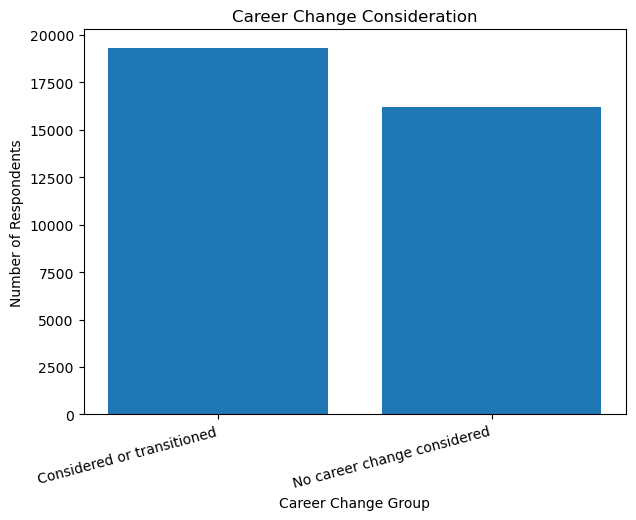

In [12]:
career_counts_plot = (
    df["career_change_considered"]
    .map(career_labels)
    .value_counts()
)

plt.figure(figsize=(7, 5))
plt.bar(career_counts_plot.index, career_counts_plot.values)
plt.xlabel("Career Change Group")
plt.ylabel("Number of Respondents")
plt.title("Career Change Consideration")
plt.xticks(rotation=15, ha="right")
plt.show()

Among respondents who answered the `NewRole` question, slightly more than half reported that they had either considered a career or industry change or had transitioned into a new career or industry in the past year. This makes the variable useful for classification because the target is relatively balanced rather than being dominated by one class.

## Job Satisfaction and Career Change Consideration

This section compares job satisfaction between respondents who did and did not consider or transition into a new career or industry.

In [13]:
df.groupby("career_change_considered")["JobSat"].agg(["count", "mean", "median", "std"])

,count,mean,median,std
career_change_considered,,,,
0.0,12178,7.785104,8.0,1.687323
1.0,14134,6.695132,7.0,2.096270


In [14]:
career_labels = {
    0.0: "No career change considered",
    1.0: "Considered or transitioned"
}

jobsat_by_career = (
    df.dropna(subset=["career_change_considered", "JobSat"])
    .assign(career_group=lambda x: x["career_change_considered"].map(career_labels))
    .groupby("career_group")["JobSat"]
    .mean()
    .sort_values(ascending=False)
)

jobsat_by_career

career_group
No career change considered    7.785104
Considered or transitioned     6.695132
Name: JobSat, dtype: float64

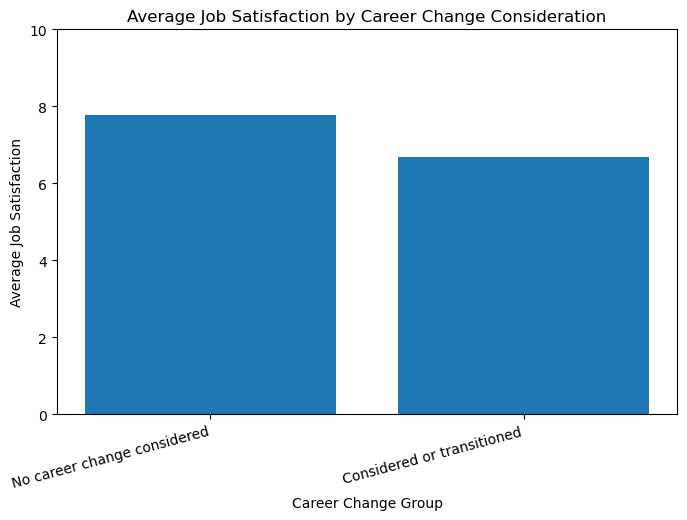

In [15]:
plt.figure(figsize=(8, 5))
plt.bar(jobsat_by_career.index, jobsat_by_career.values)
plt.xlabel("Career Change Group")
plt.ylabel("Average Job Satisfaction")
plt.title("Average Job Satisfaction by Career Change Consideration")
plt.ylim(0, 10)
plt.xticks(rotation=15, ha="right")
plt.show()

Respondents who did not consider or transition into a new career or industry reported higher average job satisfaction than those who did. This supports using job satisfaction as a meaningful workforce outcome in the project.

## Active Learners

In [16]:
df["LearnCodeChoose"].value_counts(dropna=False)

LearnCodeChoose
Yes, I am not new to coding but am learning new coding techniques or programming language      32362
No, I am not new to coding and did not learn new coding techniques or programming languages    12501
Missing                                                                                         2333
Yes, I am new to coding or currently a student                                                  1995
Name: count, dtype: int64

In [17]:
active_labels = {
    0.0: "Not active learner",
    1.0: "Active learner"
}

df.groupby("active_learner")["JobSat"].agg(["count", "mean", "median", "std"])

,count,mean,median,std
active_learner,,,,
0.0,7719,7.245369,8.0,2.003860
1.0,18933,7.183912,8.0,1.994123


In [18]:
career_by_active = (
    df.dropna(subset=["active_learner", "career_change_considered"])
    .assign(active_label=lambda x: x["active_learner"].map(active_labels))
    .groupby("active_label")["career_change_considered"]
    .mean()
    * 100
)

career_by_active

active_label
Active learner        55.976665
Not active learner    50.666792
Name: career_change_considered, dtype: float64